In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Functions for the Data Pipeline

In [2]:
# function to get list of all race id in a season
# series key for now is 'series_1' for cup, 'series_2' for xfinity, 'series_3' for trucks
def get_race_ids(year, series_key):

    race_list_url = f"https://cf.nascar.com/cacher/{year}/race_list_basic.json"
    response = requests.get(race_list_url)
    data = response.json()
    races_df = pd.DataFrame(data[series_key])
    races_df_clean = races_df[['race_id', 'series_id', 'race_season', 'track_id', 'race_name', 'race_type_id', 'actual_laps']]
    return races_df_clean


In [3]:
# function to get track information 
def get_track_info():
    track_info_url = "https://cf.nascar.com/cacher/tracks.json"
    response = requests.get(track_info_url)
    data = response.json()
    df = pd.DataFrame(data['items'])
    df = df[['track_id', 'track_name', 'track_surface', 'track_type']]
    return df

In [ ]:
# function to get lap data for a single race
def fetch_single_race(year,series_num, race_id):
    race_url = f"https://cf.nascar.com/cacher/{year}/{series_num}/{race_id}/lap-times.json"
    response = requests.get(race_url)
    data = response.json()
    # pull out lap data and create a row for each driver lap time
    df = pd.json_normalize(
        data['laps'],
        record_path='Laps',
        meta=['Number', 'FullName', 'NASCARDriverID']
    )
    # will need to adjust the flag key if more flag states are added in the future
    flag_key = {
    0: 'None',
    1: 'Green',
    2: 'Yellow',
    3: 'Red',
    4: 'White',
    5: 'Checkered',
    8: 'Hot Track',
    9: 'Cold Track'}
    # create a dataframe for flag status and merge it with the lap data
    flag_status = pd.DataFrame(data['flags'])
    flag_status["FlagName"] = flag_status["FlagState"].map(flag_key).fillna("Unknown")
    df = pd.merge(df, flag_status, left_on = 'Lap', right_on = 'LapsCompleted', how = 'left')

    return df

# function to get lap data for a list of races
def get_lap_data(year, series_num, race_ids):
    lap_data = []
    # run the single race function above for each race id
    for race_id in race_ids: 
        race_data = fetch_single_race(year, series_num,race_id)
        race_data['race_id'] = race_id
        lap_data.append(race_data)

    lap_df = pd.concat(lap_data, ignore_index=True)
    return lap_df

In [ ]:

# function to get result data for a single race
def fetch_single_result(year,series_num, race_id):
    race_url = f"https://cf.nascar.com/loopstats/prod/{year}/{series_num}/{race_id}.json"
    response = requests.get(race_url)
    data = response.json()
    # pull out lap data and create a row for each driver lap time
    df = pd.json_normalize(
        data,
        record_path='drivers',
        meta=['race_id']
    )
    df = df[['driver_id', 'ps', 'laps', 'race_id']]

    return df

# using the result function for each race in the season to get a df of all results
def get_result_data(year, series_num, race_ids):
    result_data = []
    # run the single race function above for each race id
    for race_id in race_ids: 
        race_data = fetch_single_result(year, series_num,race_id)
        race_data['race_id'] = race_id
        result_data.append(race_data)

    result_df = pd.concat(result_data, ignore_index=True)
    return result_df


In [ ]:
# function to get pit data for each race 

def fetch_pit_data(series_num, race_ids):

    #races_df = races_df[races_df['race_type_id'] == 1] 

    def fetch_single_race(series_num, race_id):
        pit_url = f"https://cf.nascar.com/cacher/live/series_{series_num}/{race_id}/live-pit-data.json"
        response = requests.get(pit_url)
        data = response.json()
        return pd.DataFrame(data)

    pit_data = []
    for race_id in race_ids:
        race_data = fetch_single_race(series_num,race_id)
        race_data['race_id'] = race_id
        pit_data.append(race_data)

    pit_df = pd.concat(pit_data, ignore_index=True)
    pit_df = pit_df[['vehicle_number', 'lap_count', 'pit_stop_type', 'left_front_tire_changed', 'right_front_tire_changed', 'left_rear_tire_changed', 'right_rear_tire_changed', 'race_id']]

    return pit_df

### Fetching Data 

In [47]:

year = 2025
series_key = 'series_1'
series_num = 1

# running the function to get the race IDs for the season
races = get_race_ids(year, series_key)
races = races[races['race_type_id'] ==1]
# create a list of race ids
race_ids = races['race_id'].tolist()


# get tracking infromation
track_df = get_track_info()

# merginging track information with the race information
races = races.merge(track_df, on='track_id', how='left')

# get lap data for each race in the season
lap_df = get_lap_data(year, series_num, race_ids)

# get result data for each race in the season
results = get_result_data(year, series_num, race_ids)

# get pit data for the season
pit_df = fetch_pit_data(series_num,race_ids)



In [392]:
# merging the results df with the lap data to get result for each race
merged_df = lap_df.merge(results, left_on=['race_id', 'NASCARDriverID'], right_on= ['race_id', 'driver_id'])
merged_df.head()

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,NASCARDriverID,LapsCompleted,FlagState,FlagName,race_id,driver_id,ps,laps
0,0,NaN,NaN,5,24,William Byron,4184,0.0,8.0,Hot Track,5546,4184,1,201
1,1,52.135,172.629,5,24,William Byron,4184,1.0,1.0,Green,5546,4184,1,201
2,2,47.861,188.045,5,24,William Byron,4184,2.0,1.0,Green,5546,4184,1,201
3,3,47.966,187.633,4,24,William Byron,4184,3.0,1.0,Green,5546,4184,1,201
4,4,47.957,187.668,2,24,William Byron,4184,4.0,1.0,Green,5546,4184,1,201


In [393]:
df = merged_df.merge(pit_df, left_on= ['race_id', 'Number', 'Lap'], right_on= ['race_id', 'vehicle_number', 'lap_count'], how='left')

In [394]:
df.head()

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,NASCARDriverID,LapsCompleted,FlagState,FlagName,...,driver_id,ps,laps,vehicle_number,lap_count,pit_stop_type,left_front_tire_changed,right_front_tire_changed,left_rear_tire_changed,right_rear_tire_changed
0,0,NaN,NaN,5,24,William Byron,4184,0.0,8.0,Hot Track,...,4184,1,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,52.135,172.629,5,24,William Byron,4184,1.0,1.0,Green,...,4184,1,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,47.861,188.045,5,24,William Byron,4184,2.0,1.0,Green,...,4184,1,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,47.966,187.633,4,24,William Byron,4184,3.0,1.0,Green,...,4184,1,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,47.957,187.668,2,24,William Byron,4184,4.0,1.0,Green,...,4184,1,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Feature Engineering

In [276]:
df.columns

Index(['Lap', 'LapTime', 'LapSpeed', 'RunningPos', 'Number', 'FullName',
       'NASCARDriverID', 'LapsCompleted', 'FlagState', 'FlagName', 'race_id',
       'driver_id', 'ps', 'laps', 'vehicle_number', 'lap_count',
       'pit_stop_type', 'left_front_tire_changed', 'right_front_tire_changed',
       'left_rear_tire_changed', 'right_rear_tire_changed'],
      dtype='str')

In [395]:
df = df.drop(columns = ['NASCARDriverID', 'lap_count', 'LapsCompleted', 'vehicle_number'])

In [396]:
df = df[df['FlagName'] == "Green"]


# adding pit stop binary column
df['PitStop'] = df['pit_stop_type'].notnull().astype(int)
df = df.rename(columns={'ps': 'Finish Position', 'Running Pos': 'Position', 'laps': 'Total Laps'})

# removing punctuations from lap speed and converting to float
df = df.replace({'LapSpeed': {',': ''}}, regex=True)
# replace NaN in LapSpeed to 0 
df = df.fillna(0)
df = df.astype({'LapSpeed': 'float', 'left_front_tire_changed': 'float', 'right_front_tire_changed': 'float', 'left_rear_tire_changed': 'float', 'right_rear_tire_changed': 'float'})

df['Avg LapSpeed'] = df.groupby(['race_id', 'Lap'])['LapSpeed'].transform('median')
df['Diff to Avg LapSpeed'] = df['LapSpeed'] - df['Avg LapSpeed']

df['Pct of Race Completed'] = df['Lap'] / df['Total Laps']

df['Speed Rank'] = df.groupby(["race_id","Lap"])["LapSpeed"].rank(ascending=False).astype(int)


df = df.sort_values(["race_id", "driver_id", "Lap"])


df['Number of Tires Changed'] = (df['left_front_tire_changed'] + df['right_front_tire_changed'] 
            + df['left_rear_tire_changed'] + df['right_rear_tire_changed'])

df['Tire Change'] = (df['Number of Tires Changed'] > 0).astype(int)

df["pit_stint"] = (
    df.groupby(["race_id", "driver_id"])["Tire Change"]
      .cumsum()
)

df["Tire Age"] = (
    df.groupby(["race_id", "driver_id", "pit_stint"])
      .cumcount()
)

df['Avg Tire Age'] = df.groupby(['race_id', 'Lap'])['Tire Age'].transform('mean')

df["Is Leader"] = (df["RunningPos"] == 1).astype(int)

df["Laps Led"] = (
    df.groupby(["race_id","driver_id"])["Is Leader"]
      .cumsum()
)

df["Avg Position L5"] = (
    df.groupby(["race_id", "driver_id"])["RunningPos"]
      .transform(
          lambda x: x.shift(1).rolling(5, min_periods=1).mean()
      )
)

df["Position Change 5"] = (
    df.groupby(["race_id","driver_id"])["RunningPos"]
      .shift(5)
      .sub(df["RunningPos"])
)

df["Avg Position"] = (
    df.groupby(["race_id", "driver_id"])["RunningPos"]
      .expanding()
      .mean()
      .reset_index(level=[0, 1], drop=True)
)

df["Is Caution"] = (df["FlagName"] == "Yellow").astype(int)
df["Is Green"] = (df["FlagName"] == "Green").astype(int)

df["Winner"] = (df["Finish Position"] <= 3).astype(int)

df = df.fillna(0)
df['Tire Age Difference'] = df['Tire Age'] - df['Avg Tire Age']
df.head()

,Lap,LapTime,LapSpeed,RunningPos,Number,FullName,FlagState,FlagName,race_id,driver_id,...,Avg Tire Age,Is Leader,Laps Led,Avg Position L5,Position Change 5,Avg Position,Is Caution,Is Green,Winner,Tire Age Difference
1619,1,51.734,173.967,20,40,* Justin Allgaier(i),1.0,Green,5546,34,...,0.0,0,0,0.000000,0.0,20.000000,0,1,0,0.0
1620,2,47.738,188.529,19,40,* Justin Allgaier(i),1.0,Green,5546,34,...,1.0,0,0,20.000000,0.0,19.500000,0,1,0,0.0
1621,3,47.830,188.166,19,40,* Justin Allgaier(i),1.0,Green,5546,34,...,2.0,0,0,19.500000,0.0,19.333333,0,1,0,0.0
1622,4,48.042,187.336,18,40,* Justin Allgaier(i),1.0,Green,5546,34,...,3.0,0,0,19.333333,0.0,19.000000,0,1,0,0.0
1623,5,48.114,187.056,16,40,* Justin Allgaier(i),1.0,Green,5546,34,...,4.0,0,0,19.000000,0.0,18.400000,0,1,0,0.0


In [397]:
df = df[df['Is Green'] == 1]
clean_df = df[['race_id', 'driver_id', 'FullName','RunningPos', 'Speed Rank', 'Diff to Avg LapSpeed', 'Lap', 'Pct of Race Completed', 'PitStop', 'Tire Age', 'Laps Led', 'Avg Position',
                 'Position Change 5','Tire Age Difference', 'Winner']]

In [398]:
x = clean_df.drop(columns = ['Winner', 'driver_id', 'FullName', 'race_id','Lap'])
y = df[['Winner']]

In [399]:
print(y.head())
x.head()

      Winner
1619       0
1620       0
1621       0
1622       0
1623       0


,RunningPos,Speed Rank,Diff to Avg LapSpeed,Pct of Race Completed,PitStop,Tire Age,Laps Led,Avg Position,Position Change 5,Tire Age Difference
1619,20,11,0.346,0.004975,0,0,0,20.000000,0.0,0.0
1620,19,19,0.260,0.009950,0,1,0,19.500000,0.0,0.0
1621,19,9,0.290,0.014925,0,2,0,19.333333,0.0,0.0
1622,18,10,0.300,0.019900,0,3,0,19.000000,0.0,0.0
1623,16,8,0.454,0.024876,0,4,0,18.400000,0.0,0.0


In [400]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(x, y, groups=clean_df["race_id"])
)

X_train = x.iloc[train_idx]
X_test = x.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [401]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced")

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

c:\Users\JG06982\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [402]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, preds)

print(f"AUC: {auc:.3f}")

AUC: 0.820


In [403]:
from sklearn.metrics import confusion_matrix
y_pred = (preds >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41786 14014]
 [ 1417  3693]]


In [404]:
df_test = clean_df.iloc[test_idx].copy()

df_test["win_probability"] = preds

In [405]:
df_test.head()

,race_id,driver_id,FullName,RunningPos,Speed Rank,Diff to Avg LapSpeed,Lap,Pct of Race Completed,PitStop,Tire Age,Laps Led,Avg Position,Position Change 5,Tire Age Difference,Winner,win_probability
67317,5558,454,Kyle Busch,7,5,2.2075,1,0.003367,0,0,0,7.0,0.0,0.0,0,0.820706
67318,5558,454,Kyle Busch,7,7,3.9610,2,0.006734,0,1,0,7.0,0.0,0.0,0,0.812745
67319,5558,454,Kyle Busch,7,8,3.2200,3,0.010101,0,2,0,7.0,0.0,0.0,0,0.810032
67324,5558,454,Kyle Busch,5,34,-10.7955,8,0.026936,0,3,0,6.5,0.0,0.0,0,0.779095
67325,5558,454,Kyle Busch,4,4,3.0545,9,0.030303,0,4,0,6.0,0.0,0.0,0,0.868360


In [406]:
race_id = 5558
driver_id = 1361	

d = df_test[
    (df_test["race_id"] == race_id) &
    (df_test["driver_id"] == driver_id)
].copy()

In [407]:
d = d.sort_values("Lap")
#print(d[["Lap", "RunningPos", "win_probability"]].tail(30))
d.tail(20)

,race_id,driver_id,FullName,RunningPos,Speed Rank,Diff to Avg LapSpeed,Lap,Pct of Race Completed,PitStop,Tire Age,Laps Led,Avg Position,Position Change 5,Tire Age Difference,Winner,win_probability
64906,5558,1361,Denny Hamlin,5,12,0.6210,272,0.915825,0,26,4,8.590517,2.0,-2.771429,1,0.693497
64907,5558,1361,Denny Hamlin,5,4,2.7110,273,0.919192,0,27,4,8.575107,2.0,-2.771429,1,0.722402
64908,5558,1361,Denny Hamlin,5,4,2.3130,274,0.922559,0,28,4,8.559829,2.0,-2.771429,1,0.722506
64909,5558,1361,Denny Hamlin,5,5,1.5070,275,0.925926,0,29,4,8.544681,1.0,-2.028571,1,0.724874
64910,5558,1361,Denny Hamlin,5,2,2.2170,276,0.929293,0,30,4,8.529661,1.0,-2.028571,1,0.735051
64911,5558,1361,Denny Hamlin,5,3,2.1070,277,0.932660,0,31,4,8.514768,0.0,-2.028571,1,0.737031
64912,5558,1361,Denny Hamlin,5,21,-0.3450,278,0.936027,0,32,4,8.500000,0.0,-2.028571,1,0.667017
64913,5558,1361,Denny Hamlin,5,10,1.0190,279,0.939394,0,33,4,8.485356,0.0,-2.028571,1,0.710433
64914,5558,1361,Denny Hamlin,5,2,2.4140,280,0.942761,0,34,4,8.470833,0.0,-2.028571,1,0.739194
64915,5558,1361,Denny Hamlin,4,11,0.4590,281,0.946128,0,35,4,8.452282,1.0,-2.941176,1,0.721543


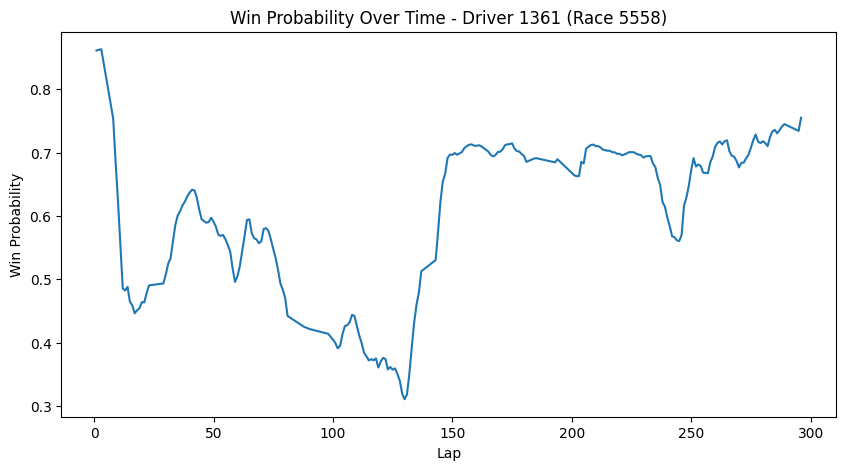

In [408]:
import matplotlib.pyplot as plt
d["win_prob_smooth"] = (
    d["win_probability"]
    .rolling(5, min_periods=1)
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(d["Lap"], d["win_prob_smooth"])

plt.xlabel("Lap")
plt.ylabel("Win Probability")
plt.title(f"Win Probability Over Time - Driver {driver_id} (Race {race_id})")

plt.show()

In [332]:
races[races["race_id"] == 5558]

,race_id,series_id,race_season,track_id,race_name,race_type_id,actual_laps,track_name,track_surface,track_type
7,5558,1,2025,4,Goodyear 400,1,297,Darlington Raceway,Asphalt,Intermediate


In [337]:
clean_df[clean_df['FullName']=='Denny Hamlin']

,race_id,driver_id,FullName,RunningPos,Speed Rank,Diff to Avg LapSpeed,Lap,Pct of Race Completed,PitStop,Tire Age,Laps Led,Avg Position,Position Change 5,Tire Age Difference,Winner
4651,5546,1361,Denny Hamlin,8,33,-0.411,1,0.004975,0,1,0,8.000000,0.0,0.000000,0
4652,5546,1361,Denny Hamlin,8,30,-0.268,2,0.009950,0,2,0,8.000000,0.0,0.000000,0
4653,5546,1361,Denny Hamlin,8,35,-0.384,3,0.014925,0,3,0,8.000000,0.0,0.000000,0
4654,5546,1361,Denny Hamlin,10,22,-0.011,4,0.019900,0,4,0,8.400000,0.0,0.000000,0
4655,5546,1361,Denny Hamlin,11,30,-0.236,5,0.024876,0,5,0,8.833333,-3.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41066,5583,1361,Denny Hamlin,5,14,0.348,262,0.981273,0,50,15,9.863118,0.0,4.542857,1
41067,5583,1361,Denny Hamlin,5,16,0.155,263,0.985019,0,51,15,9.844697,0.0,4.542857,1
41068,5583,1361,Denny Hamlin,5,7,0.727,264,0.988764,0,52,15,9.826415,0.0,3.558824,1
41069,5583,1361,Denny Hamlin,5,19,-0.053,265,0.992509,0,53,15,9.808271,0.0,3.558824,1
